# **Semana 2**

## **Introdução**

Na semana 1 vimos que a empresa *InsightPlaces* precisa de novos modelos de previsão de preços e recomendação de imóveis. Fizemos o tratamento do tipo, expandimos e tiramos colunas de nosso DataFrame, preparando para montar cada modelo solicitado, mas faltaram alguns ajustes antes de fazer um modelo de previsão de preços.

Nesta semana vamos terminar de tratar nosso dados e construíremos o modelo.

Obs.: Como este projeto se trata de um desafio proposto da Alura, vamos baixar um novo dataset em parquet supostamente tratado, pois vamos tratar colunas que já tratamos quando salvamos na semana 1.

Nesta semana utilizaremos as bibliotecas da semana 1 e as seguintes bibliotecas:

- Pandas
- Matplotlib
- Seaborn

Essas bibliotecas são apenas para a visuzalição de um gráfico de correlação que utilizaremos mais tarde.

In [77]:
# import zipfile
# import os
# import requests

# # Caminho do arquivo ZIP
# zip_url = "https://caelum-online-public.s3.amazonaws.com/challenge-spark/semana-2.zip"
# zip_path = "./Semanas_zip/semana-2.zip"
# extract_path = "./Dataset"

# # Baixar o arquivo ZIP
# response = requests.get(zip_url)
# with open(zip_path, "wb") as f:
#     f.write(response.content)

# # Extrair o conteúdo
# with zipfile.ZipFile(zip_path, "r") as zip_ref:
#     zip_ref.extractall(extract_path)

# # Listar os arquivos extraídos
# os.listdir(extract_path)

In [78]:
from pyspark.sql import SparkSession

# Inicializar o Spark
spark = SparkSession.builder.appName("ProcessamentoParquet").getOrCreate()

# Caminho do arquivo PARQUET
parquet_path = "./Dataset/dataset_transformado_parquet"

# Carregar o arquivo JSON em um DataFrame
df = spark.read.parquet(parquet_path)

# Exibir as primeiras linhas
df.show(10)

+--------------------+-----+----------+---------+---------+--------------------+-------+------+------------+------------+-----------+----+--------------------+------------+----------+----+-----+------+
|                  id|andar|area_total|area_util|banheiros|     caracteristicas|quartos|suites|tipo_anuncio|tipo_unidade|   tipo_uso|vaga|              bairro|        zona|condominio|iptu| tipo| valor|
+--------------------+-----+----------+---------+---------+--------------------+-------+------+------------+------------+-----------+----+--------------------+------------+----------+----+-----+------+
|03a386b6-7ab8-4ef...|    0|        43|       43|        1|[Churrasqueira, A...|      2|  NULL|       Usado| Apartamento|Residencial|   1|            Realengo|  Zona Oeste|       285|NULL|Venda| 22999|
|1fe78d41-b8e0-4d2...|    0|        44|       44|        1|                  []|      2|     0|       Usado| Apartamento|Residencial|   0|               Irajá|  Zona Norte|       170|   0|Vend

In [79]:
from pyspark.sql.types import IntegerType

df = df.withColumn("andar", df["andar"].cast(IntegerType()))
df = df.withColumn("banheiros", df["banheiros"].cast(IntegerType()))
df = df.withColumn("suites", df["suites"].cast(IntegerType()))
df = df.withColumn("quartos", df["quartos"].cast(IntegerType()))

## **Seleção de Features**

A seleção de features é uma etapa muito importante na construção de modelos de Machine Learning. Escolher quais colunas são importantes e descartar as irrelevantes para a análise reduz a complexidade dos dados inseridos e por consequência o modelo irá demorar menos tempo para ser ajustado.

Para começar deixaremos somente features importantes, logo estaremos retirando as colunas de `tipo_anuncio`, `tipo_unidade`, `tipo_uso` e `tipo`, utilizaremos a coluna `id` mais para frente, não retiraremos ela agora.



In [80]:
df = df.drop(*['tipo_anuncio', 'tipo_unidade', 'tipo_uso', 'tipo'])

df.show(3)

+--------------------+-----+----------+---------+---------+--------------------+-------+------+----+--------+----------+----------+----+------+
|                  id|andar|area_total|area_util|banheiros|     caracteristicas|quartos|suites|vaga|  bairro|      zona|condominio|iptu| valor|
+--------------------+-----+----------+---------+---------+--------------------+-------+------+----+--------+----------+----------+----+------+
|03a386b6-7ab8-4ef...|    0|        43|       43|        1|[Churrasqueira, A...|      2|  NULL|   1|Realengo|Zona Oeste|       285|NULL| 22999|
|1fe78d41-b8e0-4d2...|    0|        44|       44|        1|                  []|      2|     0|   0|   Irajá|Zona Norte|       170|   0|110000|
|1fa1c1e5-e98c-433...|    4|      NULL|       55|        1|                  []|      2|     0|   1|  Cosmos|Zona Oeste|      NULL|NULL|115000|
+--------------------+-----+----------+---------+---------+--------------------+-------+------+----+--------+----------+----------+----+

Perceba que as colunas `area_total` e `area_util`, possuem em muitas linhas valores iguais, isso é mostrado abaixo.

In [81]:
print('Quantas linhas são distintas entre as colunas area_total e area_util: ', df.select('*').where(df['area_total'] != df['area_util']).count())

Quantas linhas são distintas entre as colunas area_total e area_util:  1984


In [82]:
print('Quantas linhas são nulas na coluna area_total: ', df.select('area_total').na.drop().count())

Quantas linhas são nulas na coluna area_total:  57368


In [83]:
print('Quantas linhas são nulas na coluna area_util: ', df.select('area_util').na.drop().count())

Quantas linhas são nulas na coluna area_util:  66562


In [84]:
print('Quantas linhas temos ao todo: ', df.count())

Quantas linhas temos ao todo:  66562


Apenas 1984 linhas de 66562 linhas são diferentes e o resto é dado nulo, logo tiraremos a colunas `area_total` e ficaremos apenas com a coluna `area_util` como feature.

In [85]:
df = df.drop('area_total')
df.show(3)

+--------------------+-----+---------+---------+--------------------+-------+------+----+--------+----------+----------+----+------+
|                  id|andar|area_util|banheiros|     caracteristicas|quartos|suites|vaga|  bairro|      zona|condominio|iptu| valor|
+--------------------+-----+---------+---------+--------------------+-------+------+----+--------+----------+----------+----+------+
|03a386b6-7ab8-4ef...|    0|       43|        1|[Churrasqueira, A...|      2|  NULL|   1|Realengo|Zona Oeste|       285|NULL| 22999|
|1fe78d41-b8e0-4d2...|    0|       44|        1|                  []|      2|     0|   0|   Irajá|Zona Norte|       170|   0|110000|
|1fa1c1e5-e98c-433...|    4|       55|        1|                  []|      2|     0|   1|  Cosmos|Zona Oeste|      NULL|NULL|115000|
+--------------------+-----+---------+---------+--------------------+-------+------+----+--------+----------+----------+----+------+
only showing top 3 rows



## **Tratamento de Tipos**

Ao analisarmos a estrutura do nosso DataFrame, vamos notar que os tipos dos dados de cada coluna estão incorretos e por isso é necessário convertê-los.

Nisso converteremos o tipo de colunas `area_util`, `condominio`, `iptu` e `valor` para o tipo double.

In [86]:
df.printSchema()

root
 |-- id: string (nullable = true)
 |-- andar: integer (nullable = true)
 |-- area_util: string (nullable = true)
 |-- banheiros: integer (nullable = true)
 |-- caracteristicas: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- quartos: integer (nullable = true)
 |-- suites: integer (nullable = true)
 |-- vaga: long (nullable = true)
 |-- bairro: string (nullable = true)
 |-- zona: string (nullable = true)
 |-- condominio: string (nullable = true)
 |-- iptu: string (nullable = true)
 |-- valor: string (nullable = true)



In [87]:
from pyspark.sql.types import DoubleType

# Converte colunas para o tipo double
df = df.withColumn("area_util", df["area_util"].cast(DoubleType()))
df = df.withColumn("condominio", df["condominio"].cast(DoubleType()))
df = df.withColumn("iptu", df["iptu"].cast(DoubleType()))
df = df.withColumn("valor", df["valor"].cast(DoubleType()))

df.printSchema()

root
 |-- id: string (nullable = true)
 |-- andar: integer (nullable = true)
 |-- area_util: double (nullable = true)
 |-- banheiros: integer (nullable = true)
 |-- caracteristicas: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- quartos: integer (nullable = true)
 |-- suites: integer (nullable = true)
 |-- vaga: long (nullable = true)
 |-- bairro: string (nullable = true)
 |-- zona: string (nullable = true)
 |-- condominio: double (nullable = true)
 |-- iptu: double (nullable = true)
 |-- valor: double (nullable = true)



## **Tratamento de Colunas**

A coluna `caracteristicas` possui listas de `strings` como conteúdo de suas linhas. No entanto, algumas dessas listas estão sem elementos.

Vamos transformar essas listas sem elementos em valores nulos. Além do mais, a coluna não está adequada para o modelo, vamos expandir e transformar em colunas de 1 e 0.

A partir daqui utilziaremos `functions` de `pyspark.sql`.

In [88]:
import pyspark.sql.functions as f

In [89]:
df = df.withColumn('caracteristicas', f.when(f.size(df.caracteristicas) == 0, None).otherwise(df.caracteristicas))

caracteristicas = df.select(*['id', 'caracteristicas'])
caracteristicas = caracteristicas.withColumn('explode', f.explode(caracteristicas['caracteristicas']))
caracteristicas = caracteristicas.groupBy('id').pivot('explode').agg(f.lit(1)).na.fill(0)

df = df.join(caracteristicas, 'id', how='inner')
df = df.drop('caracteristicas')

df.show(5)

+--------------------+-----+---------+---------+-------+------+----+--------------------+----------+----------+------+---------+--------+------------------+-------------+------------------+--------+-------+----------+------------+-----------------+---------------+
|                  id|andar|area_util|banheiros|quartos|suites|vaga|              bairro|      zona|condominio|  iptu|    valor|Academia|Animais permitidos|Churrasqueira|Condomínio fechado|Elevador|Piscina|Playground|Portaria 24h|Portão eletrônico|Salão de festas|
+--------------------+-----+---------+---------+-------+------+----+--------------------+----------+----------+------+---------+--------+------------------+-------------+------------------+--------+-------+----------+------------+-----------------+---------------+
|fd96bbd5-d631-416...|    0|     48.0|        1|      2|     1|   1|             Camorim|Zona Oeste|       1.0|   1.0| 315000.0|       1|                 1|            1|                 1|       1|      1

Como a coluna `zona` também a categórica, também podemos expandí-la. Mas antes, note o seguinte

In [90]:
df.select('zona').distinct().show()
print("Linhas vazias totais: ", df.filter(df.zona == '').count())

+------------+
|        zona|
+------------+
|  Zona Norte|
|  Zona Oeste|
|Zona Central|
|    Zona Sul|
|            |
+------------+

Linhas vazias totais:  6


A coluna `zona` tem 6 dados nulos no total, retiraremos essas linhas e seguiremos para a expansão.

In [91]:
df = df.filter(df.zona != '')

zona = df.select(*['id', 'zona'])
zona = zona.groupBy('id').pivot('zona').agg(f.lit(1)).na.fill(0)

df = df.join(zona, 'id', how='inner')
df = df.drop('zona')

df.show(5)

+--------------------+-----+---------+---------+-------+------+----+--------------------+----------+-----+---------+--------+------------------+-------------+------------------+--------+-------+----------+------------+-----------------+---------------+------------+----------+----------+--------+
|                  id|andar|area_util|banheiros|quartos|suites|vaga|              bairro|condominio| iptu|    valor|Academia|Animais permitidos|Churrasqueira|Condomínio fechado|Elevador|Piscina|Playground|Portaria 24h|Portão eletrônico|Salão de festas|Zona Central|Zona Norte|Zona Oeste|Zona Sul|
+--------------------+-----+---------+---------+-------+------+----+--------------------+----------+-----+---------+--------+------------------+-------------+------------------+--------+-------+----------+------------+-----------------+---------------+------------+----------+----------+--------+
|00064277-de4c-4a3...|    0|    104.0|        1|      2|     0|   0|          Copacabana|    1010.0|272.0| 75

Agora que finalizamos todo o tratamento mais difícil, podemos finalmente retirar a coluna `id`. Note também que temos a coluna `bairro`, para o modelo de machine learning ele até poderia ser útil, mas essa coluna tem mais de 100 bairros distintos, o que vai sobrecarregar na hora de treinar, vamos retirá-lo também.

E por fim podemos retirar dados duplicados já que todo o tratamento mais difícil foi embora.

In [92]:
df = df.drop(*['id', 'bairro'])

df = df.dropDuplicates()

df.show(3)

+-----+---------+---------+-------+------+----+----------+------+---------+--------+------------------+-------------+------------------+--------+-------+----------+------------+-----------------+---------------+------------+----------+----------+--------+
|andar|area_util|banheiros|quartos|suites|vaga|condominio|  iptu|    valor|Academia|Animais permitidos|Churrasqueira|Condomínio fechado|Elevador|Piscina|Playground|Portaria 24h|Portão eletrônico|Salão de festas|Zona Central|Zona Norte|Zona Oeste|Zona Sul|
+-----+---------+---------+-------+------+----+----------+------+---------+--------+------------------+-------------+------------------+--------+-------+----------+------------+-----------------+---------------+------------+----------+----------+--------+
|    0|    200.0|        3|      3|     3|   3|     780.0|6323.0|1400000.0|       0|                 0|            1|                 0|       1|      1|         1|           0|                0|              1|           0|        

In [93]:
print('Quantidade total de dados: ', df.count())

Quantidade total de dados:  52591


E de 66 mil dados, diminuímos o modelo para 52 mil dados aproximadamente.

## **Tratamento de Dados Nulos**

Precisamos ainda tratar dados nulos de algumas colunas. Já sabemos que as colunas categóricas foram embora, mas ainda falta saber sobre as colunas numéricas, porém não queremos apenas retirar as linhas já que perdemos muita informação apenas retirando as duplicatas.

Precisamos saber quais colunas tem dados nulos e trateremos ela com a mediana, para não fugir muito dos dados.

In [94]:
for coluna in ['andar', 'area_util', 'banheiros', 'quartos', 'suites', 'vaga', 'condominio', 'iptu', 'valor']:
    # Procura as colunas com nulos
    nao_nulos = df.select(coluna).dropna().count()

    if  nao_nulos != 53820:
        print("Coluna: ", coluna)

        print("Quantidade de nulos antes: ", nao_nulos)

        valor = df.approxQuantile(coluna, [0.5], 0.01)[0]
        df = df.fillna({coluna: valor})

        print("Quantidade não nulos depois: ", df.select(coluna).dropna().count(), '\n')

Coluna:  andar
Quantidade de nulos antes:  52591
Quantidade não nulos depois:  52591 

Coluna:  area_util
Quantidade de nulos antes:  52591


Quantidade não nulos depois:  52591 

Coluna:  banheiros
Quantidade de nulos antes:  52591
Quantidade não nulos depois:  52591 

Coluna:  quartos
Quantidade de nulos antes:  52591
Quantidade não nulos depois:  52591 

Coluna:  suites
Quantidade de nulos antes:  48703
Quantidade não nulos depois:  52591 

Coluna:  vaga
Quantidade de nulos antes:  50841
Quantidade não nulos depois:  52591 

Coluna:  condominio
Quantidade de nulos antes:  51207
Quantidade não nulos depois:  52591 

Coluna:  iptu
Quantidade de nulos antes:  49126
Quantidade não nulos depois:  52591 

Coluna:  valor
Quantidade de nulos antes:  52591
Quantidade não nulos depois:  52591 



Tivemos um ótimo resultado substituindo os valores nulos pela mediana, mas ainda há um pequeno problema. Datasets de imóveis costumam vir muito sujos, como vimos nos tratamentos que fizemos, e sendo sujo possuem muito outliers, principalmente para casas de luxo que se destacam, mas para colunas como `banheiros`, `quartos`, `suites` e `vaga` é crítico termos valores que extrapolam o normal.

Portanto determinaremos um limite para cada uma delas e veremos quantas linhas podemos retirar.

In [95]:
for coluna in ['banheiros', 'quartos', 'suites', 'vaga']:
    print('Coluna: ', coluna)

    match coluna:
        case 'banheiros':
            print(df.select('*').where(df[coluna] >= 8).count(), '\n')
        case 'quartos':
            print(df.select('*').where(df[coluna] >= 6).count(), '\n')
        case 'suites':
            print(df.select('*').where(df[coluna] >= 6).count(), '\n')
        case 'vaga':
            print(df.select('*').where(df[coluna] >= 8).count())
        case _:
            continue


Coluna:  banheiros
229 

Coluna:  quartos
87 

Coluna:  suites
30 

Coluna:  vaga
112


E como podemos ver temos sim outliers expressivos para essas colunas, dado que os valores que estamos utilizando já são grandes para um imóvel. Aliás, estaremos tirando apenas 462 linhas de 52,5 mil.

Vamos apenas ajustar o DataFrame e seguiremos para fazer nosso modelo.

In [96]:
df = df.filter((df['suites'] < 6) & (df['quartos'] < 6))
df = df.filter((df['banheiros'] < 8) & (df['vaga'] < 8))

df.count()

52182

## **Salvando os Dados**

Após termos feito o tratamento para o modelo, iremos salvar os dados em parquet e iremos fazer nosso modelo.

In [98]:
# Escrevendo dados em parquet
df.write.parquet('./Salvamentos/dados_processados_ml_semana2_parquet')

## **Pré-Processamento e Correlação**

Agora para nosso modelo de Machine Learning falta apenas vetorizar os dados, e para isso utilizaremos o **VectorAssembler** de `pyspark.ml.feature`.

Também é importante visualizar a correlação de nossos dados para ver quais fatores podem interferir no valor final de nosso imóvel. Para isso utilizaremos as bibliotecas que citamos no início e utilizaremos também a **Correlation** de `pyspark.ml.stat`.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

Começaremos vendo como o valor se correlaciona com os nosso dados de treino.

In [ ]:
vetorizacao = VectorAssembler(inputCols=df.columns, outputCol='features')
df_correlacao = vetorizacao.transform(df)
df_correlacao = df_correlacao.select(*['features', 'valor'])
df_correlacao.show(10, truncate=False)

+---------------------------------------------------------------------------------------------------------------+---------+
|features                                                                                                       |valor    |
+---------------------------------------------------------------------------------------------------------------+---------+
|(23,[1,2,3,4,5,6,7,8,11,13,14,15,18,21],[200.0,3.0,3.0,3.0,3.0,780.0,6323.0,1400000.0,1.0,1.0,1.0,1.0,1.0,1.0])|1400000.0|
|(23,[1,2,3,4,5,6,7,8,9,11,13,14,18,21],[140.0,4.0,3.0,3.0,2.0,600.0,3600.0,990000.0,1.0,1.0,1.0,1.0,1.0,1.0])  |990000.0 |
|[0.0,753.0,3.0,3.0,3.0,2.0,4200.0,1690.0,3890000.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0]    |3890000.0|
|(23,[1,2,3,4,5,6,7,8,12,13,20],[62.0,2.0,2.0,2.0,1.0,20.0,20.0,690000.0,1.0,1.0,1.0])                          |690000.0 |
|[2.0,161.0,3.0,3.0,3.0,2.0,1.0,1.0,4311297.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0]          |4311297.0|
|(23,[1,

In [ ]:
matriz_correlacao = Correlation.corr(df_correlacao, 'features').collect()[0][0]
matriz_correlacao = matriz_correlacao.toArray()

<Axes: >

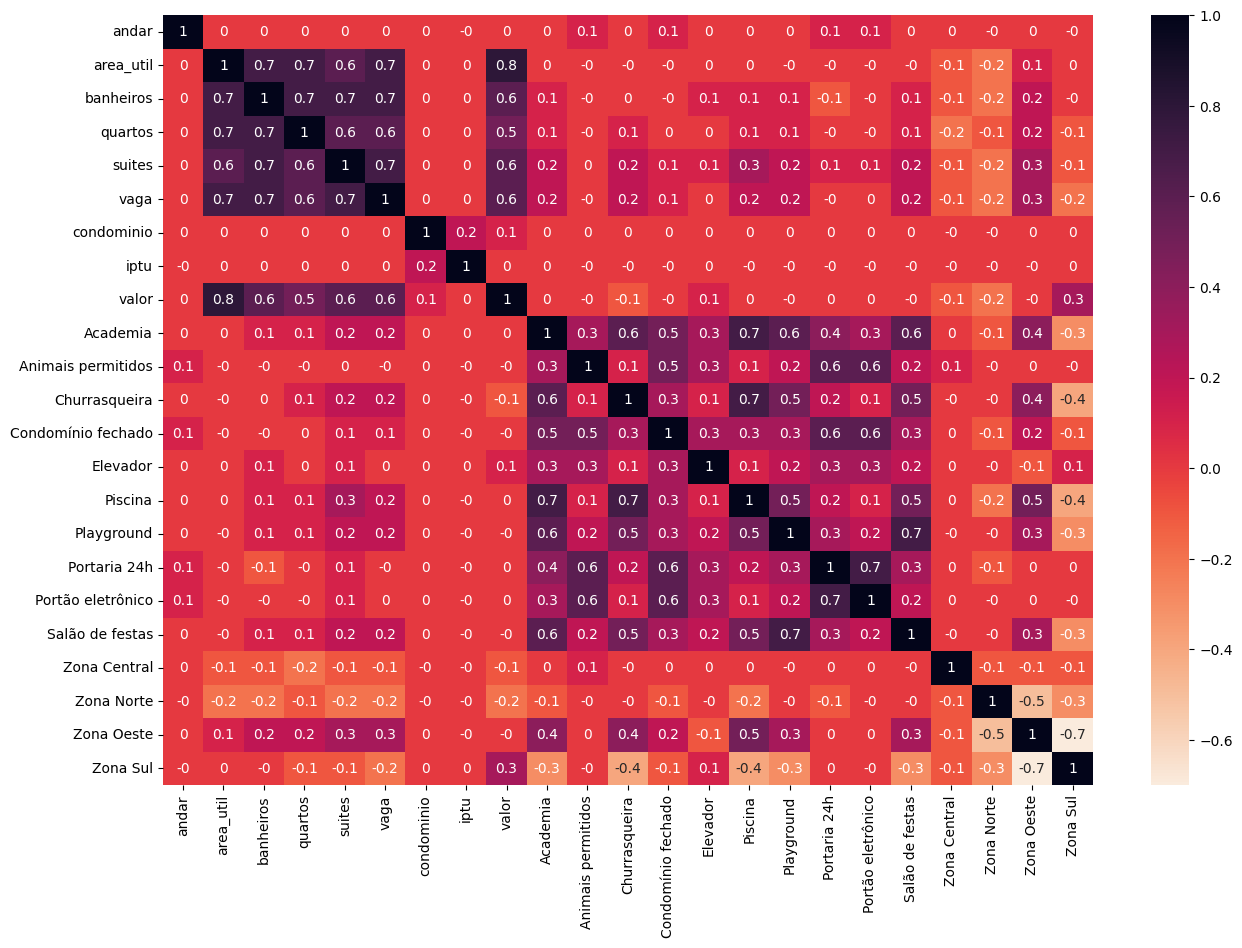

In [109]:
matriz_correlacao = pd.DataFrame(matriz_correlacao, columns=df.columns, index=df.columns)

plt.figure(figsize=(15, 10))
paleta = sns.color_palette("rocket_r", as_cmap=True)
sns.heatmap(matriz_correlacao.round(1), annot=True, cmap=paleta)

Segue do mapa que qualidades que as qualidades de uma casa estão fortemente correlacionadas com o valor o que é um grande indicativo que eles vão captar bem o valor que uma casa pode receber.

Por outro lado, características e as zonas da cidade não tiveram correlação com o valor, isso nos mostra que eles não conseguiram pegar bem o valor de uma casa, apesar de apresentarem um correlação positiva, fraca ou forte (análogo à correlação negativa).

Agora vamos fazer pré-processamento dos nossos dados sem a coluna valor para transformá-los em dados de treino.

In [111]:
X = df.columns
X.remove('valor')

In [112]:

vetorizacao = VectorAssembler(inputCols=X, outputCol='features')
df_processo = vetorizacao.transform(df)
df_processo = df_processo.select(*['features', 'valor'])
df_processo.show(10, truncate=False)

+---------------------------------------------------------------------------------------------------+---------+
|features                                                                                           |valor    |
+---------------------------------------------------------------------------------------------------+---------+
|(22,[1,2,3,4,5,6,7,10,12,13,14,17,20],[200.0,3.0,3.0,3.0,3.0,780.0,6323.0,1.0,1.0,1.0,1.0,1.0,1.0])|1400000.0|
|(22,[1,2,3,4,5,6,7,8,10,12,13,17,20],[140.0,4.0,3.0,3.0,2.0,600.0,3600.0,1.0,1.0,1.0,1.0,1.0,1.0]) |990000.0 |
|[0.0,753.0,3.0,3.0,3.0,2.0,4200.0,1690.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0]  |3890000.0|
|(22,[1,2,3,4,5,6,7,11,12,19],[62.0,2.0,2.0,2.0,1.0,20.0,20.0,1.0,1.0,1.0])                         |690000.0 |
|[2.0,161.0,3.0,3.0,3.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0]        |4311297.0|
|(22,[1,2,3,5,6,7,10,12,13,20],[55.0,1.0,1.0,1.0,1650.0,240.0,1.0,1.0,1.0,1.0])                     |820

## **Machine Learning - Regressão**

Para nosso modelo de regressão, utilizaremos o modelo **RandomForestRegressor**, dado que ele é muito robusto e vai conseguir captar bem nossos outliers em valor. Utilizaremos também dado que ele capta a não-linearidade dos dados e consegue se adaptar bem aos dados tratados com a mediana.

Para avaliarmos nosso modelo, utilizaremos os classicos classificadores: o ***R2*** (Coeficiente de Determinação) métrica que diz o quanto o seu modelo "explica" a variação dos preços dos imóveis, variando de 0 a 1, com 1 sendo seu melhor resultado; também usaremos o ***RMSE*** (Raiz do Erro Quadrático Médio) métrica que diz, em média, o quanto o seu modelo erra na mesma unidade da sua variável alvo.

In [128]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

In [129]:
treino, teste = df_processo.randomSplit([0.7, 0.3], seed=390)

print('Quantidade para treino: ', treino.count())
print('Quantidade para teste: ', teste.count())

25/12/26 19:39:41 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB


Quantidade para treino:  36417
Quantidade para teste:  15765


In [130]:
rfr = RandomForestRegressor(featuresCol='features', labelCol='valor', seed=390)
modelo = rfr.fit(treino)

previsao = modelo.transform(treino)
previsao.show(10)

+--------------------+---------+------------------+------------------+
|            features|    valor|        log(valor)|        prediction|
+--------------------+---------+------------------+------------------+
|(22,[0,1,2,3,4,5,...| 917000.0|13.728862751238601| 562659.1254362023|
|(22,[0,1,2,3,4,5,...|1050000.0|13.864300722133706|  1247388.15591762|
|(22,[0,1,2,3,4,5,...| 650000.0| 13.38472764187182| 907951.5404458534|
|(22,[0,1,2,3,4,5,...| 640000.0|13.369223455335854| 782614.8105566709|
|(22,[0,1,2,3,4,5,...|1265000.0|14.050582680143759|1540705.1301316596|
|(22,[0,1,2,3,4,5,...| 240000.0|12.388394202324129| 434658.8960494666|
|(22,[0,1,2,3,4,5,...| 365000.0| 12.80765263256463| 419309.5991712906|
|(22,[0,1,2,3,4,5,...| 727000.0|13.496681756515656| 778345.8648536068|
|(22,[0,1,2,3,4,5,...|1150000.0|13.955272500339433|1158423.6870856131|
|(22,[0,1,2,3,4,5,...|4900000.0|15.404745763080856|3688596.8290621964|
+--------------------+---------+------------------+------------------+
only s

Faremos agora a avaliação do nosso modelo

In [131]:
evaluator_rmse = RegressionEvaluator(
    labelCol="valor", predictionCol="prediction", metricName="rmse"
)
evaluator_r2 = RegressionEvaluator(
    labelCol="valor", predictionCol="prediction", metricName="r2"
)

rmse = evaluator_rmse.evaluate(previsao)
r2 = evaluator_r2.evaluate(previsao)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

RMSE: 707044.64
R²: 0.771


Para o treino ele foi concideravelmente bem em termos do ***R2***, já para o ***RMSE*** não foi o caso, ele está errando em média 700 mil reais em valor, apesar de termos casas que valam mais de 1 milhão.

Vamos avaliar para o teste.

In [132]:
previsao_teste = modelo.transform(teste)

rmse = evaluator_rmse.evaluate(previsao_teste)
r2 = evaluator_r2.evaluate(previsao_teste)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

RMSE: 688024.09
R²: 0.767


Novamente tivemos bons resultados. Percebemos que os dados se adaptaram bem não tivemos um overfitting, dado que os valores de ***R2*** e ***RMSE*** estão próximos aos dados de treino, mas ressalva novamente no caso do RMSE com 690 mil reais em erro, temos indícios de um underfiting.

### **Validação Cruzada e ParamGrid**

Antes de finalizarmos por aqui, queremos extrair o melhor de nosso modelo e ver se ele de fato está sendo um bom model. Faremos um ajuste nos hiperparâmetros e como temos valores muitos altos, o modelo talvez não esteja capitando bem, aplicaremos uma função logarítimica nos valores para deixar os valores mais próximos.

In [133]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

In [134]:
df_processo = df_processo.withColumn('log(valor)', f.log(df_processo['valor']))
df_processo.show()

+--------------------+---------+------------------+
|            features|    valor|        log(valor)|
+--------------------+---------+------------------+
|(22,[1,2,3,4,5,6,...|1400000.0|14.151982794585487|
|(22,[1,2,3,4,5,6,...| 990000.0|13.805460222110773|
|[0.0,753.0,3.0,3....|3890000.0|15.173919715594629|
|(22,[1,2,3,4,5,6,...| 690000.0|13.444446876573442|
|[2.0,161.0,3.0,3....|4311297.0|15.276749344884406|
|(22,[1,2,3,5,6,7,...| 820000.0|13.617059619240436|
|(22,[1,2,3,6,7,12...| 999230.0|13.814740261362008|
|[3.0,74.0,2.0,2.0...| 783871.0|13.571999744977893|
|(22,[1,2,3,4,5,6,...|1689998.0|14.340237903466603|
|(22,[1,2,3,4,5,6,...| 400000.0| 12.89921982609012|
|(22,[1,2,3,6,7,15...| 750000.0|13.527828485512494|
|[11.0,181.0,5.0,4...|2870000.0|14.869822587735804|
|(22,[0,1,2,3,4,5,...|1050000.0|13.864300722133706|
|(22,[1,2,3,5,6,10...| 170000.0|12.043553716032399|
|[7.0,77.0,2.0,2.0...| 999000.0| 13.81451005763069|
|(22,[0,1,2,3,6,7,...| 990000.0|13.805460222110773|
|[6.0,116.0,

In [135]:
rfr_cross = RandomForestRegressor(featuresCol='features', labelCol='log(valor)')

grid = (ParamGridBuilder().addGrid(rfr_cross.maxDepth, [5, 10])\
                         .addGrid(rfr_cross.numTrees, [10])
                         .build())

cross_validation = CrossValidator(estimator=rfr_cross,\
                                  estimatorParamMaps=grid,\
                                  evaluator=RegressionEvaluator(labelCol='log(valor)'),\
                                  numFolds=5,\
                                  seed=390)

modelo_cross = cross_validation.fit(df_processo)

25/12/26 19:40:29 WARN DAGScheduler: Broadcasting large task binary with size 1045.4 KiB
25/12/26 19:40:34 WARN DAGScheduler: Broadcasting large task binary with size 1763.4 KiB
25/12/26 19:41:14 WARN DAGScheduler: Broadcasting large task binary with size 1048.7 KiB
25/12/26 19:41:19 WARN DAGScheduler: Broadcasting large task binary with size 1768.6 KiB
25/12/26 19:41:59 WARN DAGScheduler: Broadcasting large task binary with size 1046.4 KiB
25/12/26 19:42:04 WARN DAGScheduler: Broadcasting large task binary with size 1760.4 KiB
25/12/26 19:42:46 WARN DAGScheduler: Broadcasting large task binary with size 1033.1 KiB
25/12/26 19:42:52 WARN DAGScheduler: Broadcasting large task binary with size 1736.1 KiB
25/12/26 19:43:36 WARN DAGScheduler: Broadcasting large task binary with size 1048.9 KiB
25/12/26 19:43:41 WARN DAGScheduler: Broadcasting large task binary with size 1773.3 KiB
25/12/26 19:43:54 WARN DAGScheduler: Broadcasting large task binary with size 1012.0 KiB
25/12/26 19:43:55 WAR

In [136]:
modelo_best = modelo_cross.bestModel
predicoes = modelo_best.transform(df_processo)
predicoes = predicoes.withColumn('prediction', f.exp(predicoes['prediction']))

avaliador = RegressionEvaluator(labelCol="valor", predictionCol="prediction")

r2 = avaliador.evaluate(predicoes, {avaliador.metricName: "r2"})
rmse = avaliador.evaluate(predicoes, {avaliador.metricName: "rmse"})

print(f'RMSE: {rmse:.2f}')
print(f'R2: {r2:.3f}')

RMSE: 571996.70
R2: 0.847


Como foi visto a ***R2*** e o ***RMSE*** foram melhorados e apesar de um ***RMSE*** ainda muito alto, deve-se ressaltar que os valores das nossas casas são na casas dos milhares e chegam a ultrapassar 1 milhão. Logo podemos dizer que obtivemos bons resultados.

### **GBTRegressor**

Ainda não estamos satisfeitos o suficiente para entregar nosso modelo de regressão. Apesar da grande melhora após ajustar os parâmetros da **RandomForest**, quermos algo que erre menos de 500 mil reais para estarmos confiantes em entregar um bom modelo de regressão.

Pensando nisso resolvemos utilizar o modelo **Gradient-BoostesTreeRegression**. O modelo gera árvores proceduralmente, corrigindo e melhorando os erros que árvores anteriores cometeram, garantindo assim um redução grande e efetiva de nosso erros. Com isso utilizaremos esse como nosso último modelo.

In [137]:
from pyspark.ml.regression import GBTRegressor

gbtr = GBTRegressor(featuresCol='features', labelCol='log(valor)', seed=390)

In [138]:
treino, teste = df_processo.randomSplit([0.7, 0.3], seed=390)

modelo = gbtr.fit(treino)
predicao_treino = modelo.transform(treino)
predicao_treino = predicao_treino.withColumn('prediction', f.exp(predicao_treino['prediction']))

In [139]:
r2 = avaliador.evaluate(predicao_treino, {avaliador.metricName: "r2"})
rmse = avaliador.evaluate(predicao_treino, {avaliador.metricName: "rmse"})

print(f'RMSE: {rmse:.2f}')
print(f'R2: {r2:.3f}')

RMSE: 662174.52
R2: 0.799


Para o treino tivemos um resultado razoavelmente melhor.

In [140]:
predicao_teste = modelo.transform(teste)
predicao_teste = predicao_teste.withColumn('prediction', f.exp(predicao_teste['prediction']))

In [141]:
r2 = avaliador.evaluate(predicao_teste, {avaliador.metricName: "r2"})
rmse = avaliador.evaluate(predicao_teste, {avaliador.metricName: "rmse"})

print(f'RMSE: {rmse:.2f}')
print(f'R2: {r2:.3f}')

RMSE: 658561.59
R2: 0.787


Já para o teste, apesar do ***R2*** ser melhor que no treino, o ***RMSE*** está levemente menor.

Vemos então que esse modelo tem grande capacidade ultrapassar em qualidade comparado ao **RandomForest**, por isso mexeremos em seus hiperparâmetros e aplicaremos o **Cross-Validator** para conseguirmos o melhor modelo.

In [142]:
grid_gbt = ParamGridBuilder().addGrid(gbtr.maxDepth, [5, 10])\
                             .addGrid(gbtr.stepSize, [0.07])\
                             .addGrid(gbtr.maxIter, [20])\
                             .build()

cross_gbt = CrossValidator(estimator=gbtr,
                           estimatorParamMaps=grid_gbt,\
                           evaluator=RegressionEvaluator(labelCol='log(valor)'),\
                           numFolds=5,\
                           seed=390)

modelo_cross_gbt = cross_gbt.fit(df_processo)

25/12/26 19:46:48 WARN DAGScheduler: Broadcasting large task binary with size 1008.4 KiB
25/12/26 19:46:51 WARN DAGScheduler: Broadcasting large task binary with size 1010.0 KiB
25/12/26 19:46:52 WARN DAGScheduler: Broadcasting large task binary with size 1010.4 KiB
25/12/26 19:46:53 WARN DAGScheduler: Broadcasting large task binary with size 1011.2 KiB
25/12/26 19:46:54 WARN DAGScheduler: Broadcasting large task binary with size 1012.2 KiB
25/12/26 19:46:55 WARN DAGScheduler: Broadcasting large task binary with size 1014.4 KiB
25/12/26 19:46:56 WARN DAGScheduler: Broadcasting large task binary with size 1019.0 KiB
25/12/26 19:46:57 WARN DAGScheduler: Broadcasting large task binary with size 1028.0 KiB
25/12/26 19:46:58 WARN DAGScheduler: Broadcasting large task binary with size 1045.6 KiB
25/12/26 19:47:00 WARN DAGScheduler: Broadcasting large task binary with size 1076.4 KiB
25/12/26 19:47:03 WARN DAGScheduler: Broadcasting large task binary with size 1130.7 KiB
25/12/26 19:47:06 WAR

In [143]:
gbtr_best = modelo_cross_gbt.bestModel

predicoes_gbt = gbtr_best.transform(df_processo)

predicoes_gbt = predicoes_gbt.withColumn('prediction', f.exp(predicoes_gbt['prediction']))
predicoes_gbt.show(10)

+--------------------+---------+------------------+------------------+
|            features|    valor|        log(valor)|        prediction|
+--------------------+---------+------------------+------------------+
|(22,[1,2,3,4,5,6,...|1400000.0|14.151982794585487|1492863.3999926285|
|(22,[1,2,3,4,5,6,...| 990000.0|13.805460222110773| 703514.2801509025|
|[0.0,753.0,3.0,3....|3890000.0|15.173919715594629| 4613816.230547475|
|(22,[1,2,3,4,5,6,...| 690000.0|13.444446876573442| 605415.6463491773|
|[2.0,161.0,3.0,3....|4311297.0|15.276749344884406| 2843650.287997252|
|(22,[1,2,3,5,6,7,...| 820000.0|13.617059619240436| 752612.2493494537|
|(22,[1,2,3,6,7,12...| 999230.0|13.814740261362008| 853785.1006822779|
|[3.0,74.0,2.0,2.0...| 783871.0|13.571999744977893| 801707.5168464531|
|(22,[1,2,3,4,5,6,...|1689998.0|14.340237903466603|1758189.4737533242|
|(22,[1,2,3,4,5,6,...| 400000.0| 12.89921982609012|  601845.468985419|
+--------------------+---------+------------------+------------------+
only s

In [144]:
r2 = avaliador.evaluate(predicoes_gbt, {avaliador.metricName: "r2"})
rmse = avaliador.evaluate(predicoes_gbt, {avaliador.metricName: "rmse"})

print(f'RMSE: {rmse:.2f}')
print(f'R2: {r2:.3f}')

RMSE: 476786.00
R2: 0.894


Finalmente quando melhorado os hiperparâmetros conseguimos o melhor resultado até o momento, com ***R2*** = 0.894 e ***RMSE*** = 476800, concluindo o aprendizado do nosso melhor modelo.

## **Conclusão**

Com nosso modelo, somos capazes de prever o preço de um imóvel a partir de qualidades gerais dele. Vimos um grande salto de qualidade do **GTBRegressor** comparado ao **RandomForest**, errando, em média, até menos que 476,8 mil reais em um todo dos nossos dados.

Com esse modelo, quem for fazer a estipulação do preço de um dado imóvel, deve-se atentar aos principais aspectos dele. Com nosso gráfico de correlação, vimos o que mais influência na hora de avaliar são a `area_util`, `banheiros`, `quartos`, `suites` e `vaga`. Portanto usando como base os valores a predição que o **GTBRegressor** pode trazer, baseie-se nas casas com as principais características que fazem bastante diferença na hora de calcular o preço, uma vez nosso modelo é suscetível a erros, não trazendo uma previsão perfeita. No final ele serve para guiar para uma visão de negócio, aproximando brilhantemente aos valores que cada imóvel de fato tem, assim podemos tomar as melhores decisões de negócios e indicar as melhores ofertas para os clientes.